# A spatial code across several tissue sections

Cells that sit next to each other in a tissue are the ones most able to talk. If a
ligand-receptor pair is part of how the tissue is organised, then the cell types that use
it heavily should be the cell types found close together — and a pair that has nothing to
do with spatial organisation should show no such agreement.

This notebook searches for that subset of pairs in **single-cell resolution spatial data**
— Xenium, MERFISH, CosMx — where every cell has coordinates and a cell type. It is the
same genetic-algorithm search as in
[Identifying a spatial code of ligand-receptor pairs](../Genetic-Algorithm-LR-Selection/),
applied to the situation you usually have in practice: **several sections**, not one.

The whole pipeline is four steps, and only the last one is the search:

```
   single cells                 cell types                    the search
   with coordinates
                                                          .-----------------.
   cell  x  y  type   --.                                 | pick a subset   |
   c1   12  4   T      |   how close, or                  | of LR pairs     |
   c2   15  9   T      |   how colocalised,       ----->  | so the two      |
   c3   80  2   F      |   is each cell type      ----->  | matrices agree  |
   ...                 |   to each other?                 '-----------------'
                       |         (a cell type x cell type reference)               |
                       |                                                           v
                       '-> fraction of cells of each type                    the spatial
                           expressing each gene                              code
                                (a gene x cell type matrix)
```

Two ways of using the sections are shown, because they answer different questions:

- **Pooled** — put every cell from every section into one matrix and search once. Answers
  *what does this tissue do*, and is the right thing when the sections are replicates.
- **Per section, then a consensus** — search each section on its own and keep the pairs
  that several sections agree on. Answers *what holds up across samples*, and is what you
  want when sections differ, which they always do.

The data here is simulated, so a known subset of pairs really is the spatial code and the
answers can be checked. With real data you cannot do that, which is exactly why the
consensus and the held-out check at the end matter.

**Requirements.** `pip install cell2cell[ga]`, which adds `pygad` to the search.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cell2cell as c2c

np.set_printoptions(legacy='1.25')

## 1. Several sections of tissue

Each section is a set of single cells: a position, a cell type, and counts for the ligands
and receptors on the panel. Eight cell types sit at anchor points that shift a little from
section to section, the way real sections of the same tissue differ.

Twelve of the eighty ligand-receptor pairs are **the spatial code**: each one is switched
on in the cell types nearest its own anchor, so two cell types lying close together end up
sharing more active pairs than two lying far apart. The other sixty-eight are switched on
in cell types picked at random, redrawn independently in every section — they carry no
spatial information and no consistency between sections.

A code pair is also missing altogether from roughly one section in seven. That is the
detail that makes a single section an unreliable witness, and it is the reason the
consensus later has something to do.

In [2]:
N_TYPES, N_CODE, N_BACKGROUND = 8, 12, 68
CELLS_PER_TYPE = 30


def simulate_section(seed, jitter=14.0, dropout=0.15):
    """Single cells from one tissue section, with a planted spatial code.

    Returns the counts (cells x genes), a frame of coordinates and cell types, the
    ligand-receptor panel, and the names of the pairs that really are the code.
    """
    rng = np.random.default_rng(seed)

    # Cell types sit around a ring, nudged a little in each section
    angles = np.linspace(0, 2 * np.pi, N_TYPES, endpoint=False)
    anchors = np.c_[np.cos(angles), np.sin(angles)] * 40 + 50
    anchors = anchors + rng.normal(0, jitter, anchors.shape)

    n_pairs = N_CODE + N_BACKGROUND
    ligands = ['L{:02d}'.format(i) for i in range(n_pairs)]
    receptors = ['R{:02d}'.format(i) for i in range(n_pairs)]

    # Which cell types express each pair
    active = np.zeros((n_pairs, N_TYPES), dtype=bool)
    for k in range(n_pairs):
        if k < N_CODE and rng.random() >= dropout:
            # A code pair: on in its own anchor cell type and its two nearest neighbours
            distance = np.linalg.norm(anchors - anchors[k % N_TYPES], axis=1)
            active[k] = distance <= np.sort(distance)[2]
        else:
            # Background, and code pairs that happen to be absent from this section
            active[k, rng.choice(N_TYPES, size=3, replace=False)] = True

    blocks, coordinates, celltypes = [], [], []
    for t in range(N_TYPES):
        coordinates.append(anchors[t] + rng.normal(0, 6.0, (CELLS_PER_TYPE, 2)))
        # A cell of this type expresses an active gene most of the time, and an
        # inactive one only occasionally -- the dropout of the assay
        probability = np.where(active[:, t], 0.6, 0.04)
        blocks.append(np.c_[rng.random((CELLS_PER_TYPE, n_pairs)) < probability,
                            rng.random((CELLS_PER_TYPE, n_pairs)) < probability
                            ].astype(float))
        celltypes += ['CT-{}'.format(t + 1)] * CELLS_PER_TYPE

    barcodes = ['S{}-cell-{}'.format(seed + 1, i) for i in range(len(celltypes))]
    counts = pd.DataFrame(np.vstack(blocks), index=barcodes,
                          columns=ligands + receptors)
    cells = pd.DataFrame(np.vstack(coordinates), index=barcodes, columns=['X', 'Y'])
    cells['celltype'] = celltypes
    cells['sample_id'] = 'section-{}'.format(seed + 1)

    lr_pairs = pd.DataFrame({'A': ligands, 'B': receptors})
    code = ['{}^{}'.format(a, b)
            for a, b in zip(ligands[:N_CODE], receptors[:N_CODE])]
    return counts, cells, lr_pairs, code

In [3]:
SECTIONS = ['section-{}'.format(i + 1) for i in range(5)]

counts, cells, lr_pairs, code = {}, {}, None, None
for i, name in enumerate(SECTIONS):
    counts[name], cells[name], lr_pairs, code = simulate_section(seed=i)

# One table of cells, one of counts, with sample_id telling them apart
all_cells = pd.concat(cells.values())
all_counts = pd.concat(counts.values())

print('{} sections, {} cells in total, {} genes'.format(
    len(SECTIONS), all_cells.shape[0], all_counts.shape[1]))
print('{} ligand-receptor pairs, of which {} are the planted spatial code'.format(
    len(lr_pairs), len(code)))
all_cells.head()

5 sections, 1200 cells in total, 160 genes
80 ligand-receptor pairs, of which 12 are the planted spatial code


,X,Y,celltype,sample_id
S1-cell-0,88.924697,51.668556,CT-1,section-1
S1-cell-1,87.779012,44.470025,CT-1,section-1
S1-cell-2,82.129327,52.526628,CT-1,section-1
S1-cell-3,96.597059,45.292271,CT-1,section-1
S1-cell-4,92.740263,40.394655,CT-1,section-1


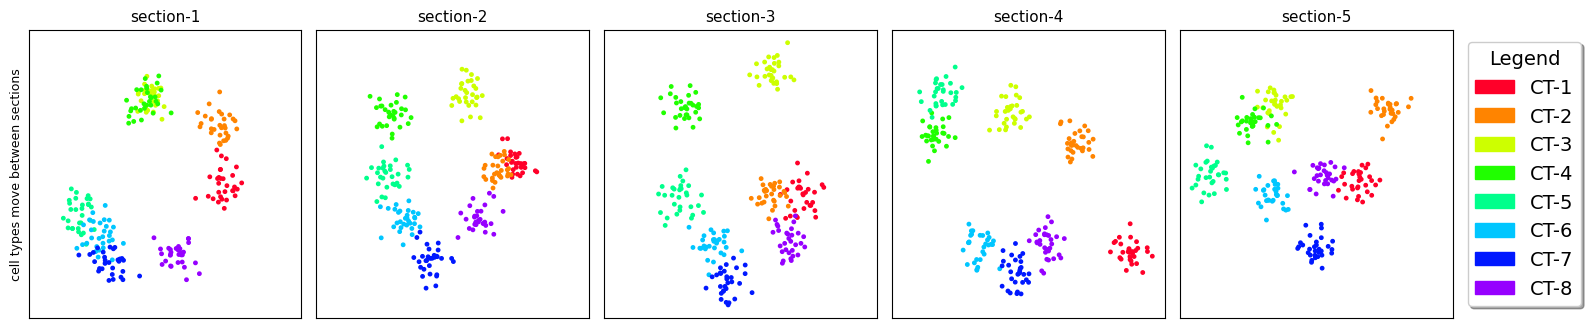

In [4]:
fig, axes = plt.subplots(1, len(SECTIONS), figsize=(16, 3.4), sharex=True, sharey=True)
colors = c2c.plotting.get_colors_from_labels(sorted(all_cells['celltype'].unique()))
for ax, name in zip(axes, SECTIONS):
    section = cells[name]
    ax.scatter(section['X'], section['Y'], s=6,
               c=[colors[t] for t in section['celltype']])
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
axes[0].set_ylabel('cell types move between sections', fontsize=9)
c2c.plotting.generate_legend(colors, ax=axes[-1], bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

## 2. The reference: how close, or how colocalised

The search needs a number for every pair of cell types saying how spatially associated they
are. There are two natural choices and `cell2cell` treats them the same way, because the
search only ever asks whether its own cell-cell scores *agree* with the reference.

**Distance** is the simpler one. `celltype_distances` reduces each cell type to a centroid
and measures between them, so a small number means close together.

In [5]:
# Only the coordinates and the cell type: a centroid is a mean over the columns, so
# anything else in the frame -- sample_id here -- has to be left out
COORDS = ['X', 'Y', 'celltype']

distances = {name: c2c.spatial.celltype_distances(frame[COORDS], group_col='celltype',
                                                  method='centroid')
             for name, frame in cells.items()}
distances['section-1'].round(1).iloc[:5, :5]

celltype,CT-1,CT-2,CT-3,CT-4,CT-5
celltype,,,,,
CT-1,0.0,31.0,64.5,65.5,92.4
CT-2,31.0,0.0,45.7,48.2,100.0
CT-3,64.5,45.7,0.0,3.7,75.8
CT-4,65.5,48.2,3.7,0.0,72.4
CT-5,92.4,100.0,75.8,72.4,0.0


**Colocalisation** is usually the better one, and it is what you would compute from
Xenium. Instead of collapsing a cell type to its centre, it counts how often cells of two
types are actually found within a short radius of each other, and compares that to what
would happen if the cell type labels were shuffled. A pair of types that neighbour each
other more than chance allows scores high.

That matters when a cell type is scattered rather than clumped: its centroid can sit
somewhere no cell of that type actually is, while the neighbour count stays honest.

`cell2cell` has no function for this — it is an analysis choice rather than a primitive, and
`squidpy.gr.nhood_enrichment` does it well if you already use squidpy — so here it is
written out, which also makes explicit what the number means.

In [6]:
from sklearn.neighbors import NearestNeighbors


def colocalization_enrichment(frame, group_col='celltype', coord_cols=('X', 'Y'),
                              radius=55.0, n_permutations=200, random_state=0):
    """How much more often two cell types neighbour each other than chance allows.

    Counts the pairs of cells of each type combination lying within `radius`, then
    repeats the count with the cell type labels shuffled. `radius` is the parameter
    that matters: it has to be large enough to reach from one cell type into the next,
    or every off-diagonal entry comes back at roughly the same uninformative value. The score is a z-score: how
    far the real count sits from the shuffled ones, in their own standard deviations.
    Positive means colocalised, negative means the two types avoid each other.
    """
    rng = np.random.default_rng(random_state)
    labels = np.asarray(frame[group_col])
    types = sorted(pd.unique(labels))
    index = {t: i for i, t in enumerate(types)}

    # Every pair of cells closer than `radius`, once each
    neighbours = NearestNeighbors(radius=radius).fit(frame.loc[:, list(coord_cols)])
    pairs = neighbours.radius_neighbors_graph(mode='connectivity').tocoo()
    left, right = pairs.row, pairs.col
    keep = left < right
    left, right = left[keep], right[keep]

    def counts_for(assignment):
        table = np.zeros((len(types), len(types)))
        a = [index[t] for t in assignment[left]]
        b = [index[t] for t in assignment[right]]
        np.add.at(table, (a, b), 1.0)
        np.add.at(table, (b, a), 1.0)
        return table

    observed = counts_for(labels)
    null = np.stack([counts_for(rng.permutation(labels))
                     for _ in range(n_permutations)])
    spread = null.std(axis=0)
    spread[spread == 0] = 1.0            # a combination that never occurs
    enrichment = (observed - null.mean(axis=0)) / spread
    return pd.DataFrame(enrichment, index=types, columns=types)

In [7]:
colocalization = {name: colocalization_enrichment(frame)
                  for name, frame in cells.items()}
colocalization['section-1'].round(1).iloc[:5, :5]

,CT-1,CT-2,CT-3,CT-4,CT-5
CT-1,20.9,30.2,-14.9,-16.1,-22.6
CT-2,30.2,19.9,22.7,16.9,-23.1
CT-3,-14.9,22.7,18.1,30.1,-22.0
CT-4,-16.1,16.9,30.1,20.7,-22.3
CT-5,-22.6,-23.1,-22.0,-22.3,21.2


The two carry the same information with opposite signs — cell types that are close have a
small distance and a high enrichment — and the search does not care which it gets. Its fitness
is the *absolute* correlation by default, so the sign only decides whether the number it
reports is positive or negative.

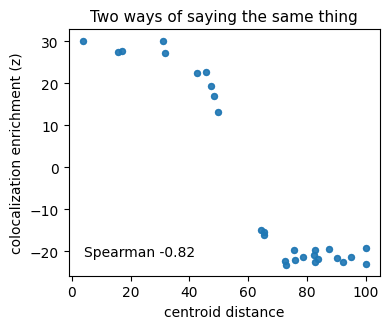

In [8]:
fig, ax = plt.subplots(figsize=(4, 3.4))
off_diagonal = ~np.eye(len(colocalization['section-1']), dtype=bool)
ax.scatter(distances['section-1'].values[off_diagonal],
           colocalization['section-1'].values[off_diagonal], s=18, alpha=0.7)
ax.set_xlabel('centroid distance')
ax.set_ylabel('colocalization enrichment (z)')
ax.set_title('Two ways of saying the same thing', fontsize=11)
from scipy.stats import spearmanr
rho = spearmanr(distances['section-1'].values[off_diagonal],
                colocalization['section-1'].values[off_diagonal])[0]
ax.annotate('Spearman {:.2f}'.format(rho), xy=(0.05, 0.08), xycoords='axes fraction')
plt.tight_layout()
plt.show()

# The rest of the notebook uses one of them. Centroid distance is the steadier of the
# two on data shaped like this, where each cell type forms one compact clump; swap in
# `colocalization` when your cell types are dispersed and a centroid would fall
# somewhere none of their cells actually are.
reference = distances
pooled_reference = c2c.spatial.celltype_distances(all_cells[COORDS],
                                                  group_col='celltype',
                                                  method='centroid')

## 3. From single cells to cell types

The search compares cell *types*, so the single cells have to be summarised into one column
per type. `aggregate_single_cells` does that, and for spatial panels the useful summary is
`nn_cell_fraction`: **the fraction of cells of that type in which the gene was detected**.

A mean is dragged around by a few bright cells and by how deeply each section was measured.
A fraction is not — it asks how *widespread* a gene is in a cell type, which is the question
that matters when deciding whether a cell type can use a ligand-receptor pair at all.

A gene then counts as active in a cell type when that fraction clears a cutoff. Five to ten
per cent is the usual range: below it you are picking up ambient signal and misassigned
transcripts, and above it you start losing genes that are genuinely restricted to a
subpopulation. Here `expression_thresholding` turns the fractions into on/off, and
`jaccard` scores a pair of cell types by how much of their active sets they share.

In [9]:
def fractions_for(section_names):
    '''Fraction of cells of each type expressing each gene, over the sections given.'''
    barcodes = all_cells.index[all_cells['sample_id'].isin(section_names)]
    metadata = pd.DataFrame({'barcodes': barcodes,
                             'cell_types': all_cells.loc[barcodes, 'celltype'].values})
    return c2c.preprocessing.rnaseq.aggregate_single_cells(
        rnaseq_data=all_counts.loc[barcodes], metadata=metadata,
        method='nn_cell_fraction')


fractions = {name: fractions_for([name]) for name in SECTIONS}
fractions['section-1'].round(2).iloc[:5, :5]

,CT-1,CT-2,CT-3,CT-4,CT-5
L00,0.60,0.57,0.07,0.03,0.03
L01,0.60,0.67,0.63,0.00,0.00
L02,0.07,0.70,0.63,0.60,0.00
L03,0.03,0.73,0.67,0.57,0.00
L04,0.60,0.03,0.07,0.10,0.03


In [10]:
CUTOFF = 0.10

analysis_setup = {'communication_score': 'expression_thresholding',
                  'cci_score': 'jaccard',
                  'cci_type': 'undirected'}
cutoff_setup = {'type': 'constant_value', 'parameter': CUTOFF}

active = (fractions['section-1'] >= CUTOFF)
print('genes called active in at least one cell type: {} of {}'.format(
    int(active.any(axis=1).sum()), active.shape[0]))
print('active genes per cell type: {}'.format(
    ', '.join('{} {}'.format(t, int(n)) for t, n in active.sum().items())))

genes called active in at least one cell type: 160 of 160
active genes per cell type: CT-1 72, CT-2 80, CT-3 69, CT-4 73, CT-5 67, CT-6 59, CT-7 100, CT-8 66


## 4. One search over everything

The simplest thing to do with several sections is to ignore that they are several: pool
every cell into one table, aggregate once, and search once. The reference is the
colocalisation computed over all the cells together.

This is the right choice when the sections really are replicates of the same tissue and you
want the most data behind a single answer. It is the wrong choice when they differ in a way
you care about, because pooling averages that away.

In [11]:
pooled_fractions = fractions_for(SECTIONS)

pooled_objective = c2c.analysis.CorrelationObjective(
    rnaseq_data=pooled_fractions,
    reference_distances=pooled_reference,
    cutoff_setup=cutoff_setup,
    analysis_setup=analysis_setup)

pooled = c2c.analysis.optimize_lr_pairs(
    ppi_data=lr_pairs, objective=pooled_objective,
    population_size=60, generations=40, runs=3, random_state=0)

print('fitness {:.3f}, {} of {} pairs kept'.format(
    pooled['best_obj_fn'], len(pooled['best_ppi_data']), len(lr_pairs)))

fitness 0.923, 40 of 80 pairs kept


To see which pairs those are, take the **mask**, not the returned table. Each `runN` entry
holds a 0/1 vector over the rows of `results['pool']`, which is what maps a selection back
onto pair names. `best_ppi_data` is a convenience view whose index has been reset, so its row
numbers are not positions in the pool.

In [12]:
def selected_keys(results, run=None):
    """Names of the pairs a search kept, as 'ligand^receptor'."""
    run = run or results['final_run']
    mask = np.asarray(results[run]['ppi_data'], dtype=bool)
    pool = results['pool']
    return ['{}^{}'.format(a, b) for a, b in pool.loc[mask, ['A', 'B']].values]


def score_selection(keys):
    """How much of the planted code a selection found, and how much of it is code."""
    keys = set(keys)
    found = keys & set(code)
    return pd.Series({'selected': len(keys),
                      'of which code': len(found),
                      'precision': len(found) / max(len(keys), 1),
                      'recall': len(found) / len(code)})


pooled_keys = selected_keys(pooled)
score_selection(pooled_keys).round(2)

selected         15.00
of which code     5.00
precision         0.33
recall            0.42
dtype: float64

## 5. One search per section, then a consensus

Now the other way. Each section gets its own reference, its own aggregated expression, and
its own search — and the searches disagree, for two separate reasons.

The first is that a genetic algorithm returns a *local* optimum: run it twice with different
seeds on the same data and it lands on different, overlapping sets. `executions` handles that
by running the search several times within a section and recording how often each pair
survives.

The second is biological, and is the one worth caring about: a pair that is genuinely part of
the code in one section may be absent from the next. No single section can tell those two
causes apart. Agreement *across* sections can.

In [13]:
per_section = {}
for i, name in enumerate(SECTIONS):
    objective = c2c.analysis.CorrelationObjective(
        rnaseq_data=fractions[name],
        reference_distances=reference[name],
        cutoff_setup=cutoff_setup,
        analysis_setup=analysis_setup,
        validate_fast=False)
    per_section[name] = c2c.analysis.optimize_lr_pairs(
        ppi_data=lr_pairs, objective=objective, population_size=60, generations=40,
        runs=3, executions=8, random_state=100 * i)
    print('{}: fitness {:.3f}, {} pairs kept by the final run'.format(
        name, per_section[name]['best_obj_fn'],
        len(selected_keys(per_section[name]))))

section-1: fitness 0.957, 21 pairs kept by the final run


section-2: fitness 0.968, 25 pairs kept by the final run


section-3: fitness 0.953, 19 pairs kept by the final run


section-4: fitness 0.985, 10 pairs kept by the final run


section-5: fitness 0.955, 19 pairs kept by the final run


Each section now carries a **selection frequency**: for every pair, the fraction of that
section's eight executions that kept it. Stacking those five vectors gives one number per pair
per section, which is the whole consensus in one table.

In [14]:
keys = ['{}^{}'.format(a, b) for a, b in lr_pairs[['A', 'B']].values]

frequency = pd.DataFrame(
    {name: c2c.analysis.lr_selection_frequency(results['selection_masks'])
     for name, results in per_section.items()},
    index=keys)
frequency['mean'] = frequency[SECTIONS].mean(axis=1)
frequency['is code'] = [k in set(code) for k in keys]

frequency.sort_values('mean', ascending=False).head(12).round(2)

,section-1,section-2,section-3,section-4,section-5,mean,is code
L06^R06,0.88,1.00,0.50,0.62,1.00,0.80,True
L05^R05,1.00,0.88,0.88,0.50,0.38,0.72,True
L01^R01,0.38,0.88,0.75,0.88,0.38,0.65,True
L02^R02,0.62,0.88,0.75,0.25,0.50,0.60,True
L09^R09,0.62,0.50,0.50,0.38,0.75,0.55,True
L08^R08,0.75,0.62,0.50,0.62,0.25,0.55,True
L04^R04,0.25,0.75,0.25,1.00,0.38,0.52,True
L07^R07,0.12,0.75,0.38,0.88,0.25,0.48,True
L25^R25,0.00,0.88,0.00,0.88,0.25,0.40,False
L11^R11,0.00,0.50,0.00,0.75,0.75,0.40,True


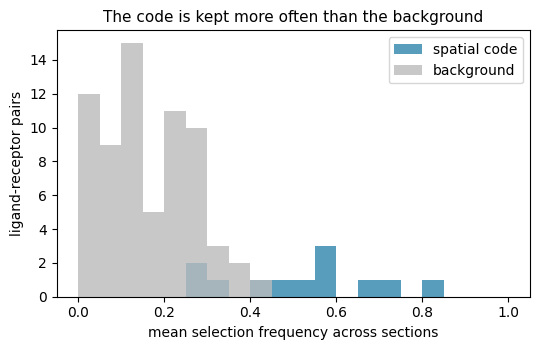

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for is_code, label, color in [(True, 'spatial code', '#2E86AB'),
                              (False, 'background', '#bbbbbb')]:
    subset = frequency.loc[frequency['is code'] == is_code, 'mean']
    ax.hist(subset, bins=np.linspace(0, 1, 21), alpha=0.8, label=label, color=color)
ax.set_xlabel('mean selection frequency across sections')
ax.set_ylabel('ligand-receptor pairs')
ax.set_title('The code is kept more often than the background', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

The two groups separate, but they overlap: no single threshold splits them cleanly, which is
the honest situation with real data too. What the consensus buys is a better *ranking* than
any one section produces.

In [16]:
top = 12
ranked = frequency.sort_values('mean', ascending=False)

comparison = pd.DataFrame(
    {name: score_selection(frequency[name].sort_values(ascending=False).head(top).index)
     for name in SECTIONS}).T
comparison.loc['all five, pooled frequency'] = score_selection(ranked.head(top).index)
comparison[['of which code', 'precision', 'recall']].round(2)

,of which code,precision,recall
section-1,6.0,0.50,0.50
section-2,8.0,0.67,0.67
section-3,4.0,0.33,0.33
section-4,6.0,0.50,0.50
section-5,4.0,0.33,0.33
"all five, pooled frequency",9.0,0.75,0.75


Every individual section does worse than the five together. That is the argument for the
consensus in one table: nothing about any single section's search was wrong, they are each
fitting their own noise, and the noise does not agree while the signal does.

`cell2cell` also offers a less arbitrary way to cut the ranking than "take the top twelve".
`lr_cooccurrence` asks how often each pair of *pairs* is selected *together*, and
`consensus_from_cooccurrence` clusters that, so pairs that travel together end up in one
group. Two pairs that are both part of the code should keep turning up in the same
selections; a background pair drifts in and out on its own.

Give it every execution from every section rather than one summary per section — with only
five vectors the co-occurrences are too coarse to cluster, and a handful of background pairs
that happened to coincide look just as tight as the real thing. `min_frequency` drops the
pairs that are barely ever selected before clustering, which otherwise dominate.

In [17]:
# Every execution of every section: 5 sections x 8 executions
all_masks = np.vstack([results['selection_masks']
                       for results in per_section.values()])
print('{} selections over {} pairs'.format(*all_masks.shape))

cooccurrence = c2c.analysis.lr_cooccurrence(all_masks, labels=keys)
chosen, clusters, scores = c2c.analysis.consensus_from_cooccurrence(
    cooccurrence, n_clusters=2, select='cooccurrence',
    frequency=c2c.analysis.lr_selection_frequency(all_masks), min_frequency=0.25)

print('cluster sizes: {}'.format({k: len(v) for k, v in clusters.items()}))
print('mean co-occurrence per cluster: {}'.format(
    {k: round(v, 2) for k, v in scores.items()}))
score_selection(chosen).round(2)

40 selections over 80 pairs
cluster sizes: {1: 11, 2: 17}
mean co-occurrence per cluster: {1: 0.3, 2: 0.31}


selected         17.00
of which code    10.00
precision         0.59
recall            0.83
dtype: float64

## 6. Leave one section out

The check most worth doing, and the one most often skipped. Everything above was chosen using
all five sections, so a good-looking result proves nothing on its own: the selection has seen
every section it is being judged on.

So: build the consensus from four sections, then score it on the fifth, which took no part in
choosing it. The number to beat is not zero — it is what a **random set of the same size**
scores on that held-out section. A selection that cannot beat random out of sample has fitted
noise, however good its training fitness looked.

In [18]:
def held_out_fitness(section, selection, n_random=100, random_state=0):
    '''Fitness of a selection on a section that did not help choose it.'''
    objective = c2c.analysis.CorrelationObjective(
        rnaseq_data=fractions[section],
        reference_distances=reference[section],
        cutoff_setup=cutoff_setup, analysis_setup=analysis_setup,
        validate_fast=False)
    bound = objective(lr_pairs)

    chosen = np.array([k in set(selection) for k in keys], dtype=float)
    rng = np.random.default_rng(random_state)
    random_masks = np.array([rng.permutation(chosen) for _ in range(n_random)])
    return bound(chosen[None, :])[0], bound(random_masks)


rows = []
for held_out in SECTIONS:
    trained_on = [s for s in SECTIONS if s != held_out]
    # The consensus, built without ever looking at the held-out section
    consensus = (frequency.loc[:, trained_on].mean(axis=1)
                 .sort_values(ascending=False).head(top).index)
    fitted, random_scores = held_out_fitness(held_out, consensus)
    rows.append({'held out': held_out,
                 'consensus fitness': fitted,
                 'random mean': random_scores.mean(),
                 'random 95th': np.percentile(random_scores, 95),
                 'beats random': fitted > np.percentile(random_scores, 95),
                 'code found': len(set(consensus) & set(code))})

pd.DataFrame(rows).set_index('held out').round(3)

,consensus fitness,random mean,random 95th,beats random,code found
held out,,,,,
section-1,0.683,0.193,0.434,True,10
section-2,0.550,0.177,0.443,True,8
section-3,0.440,0.177,0.390,True,10
section-4,0.515,0.217,0.511,True,9
section-5,0.579,0.214,0.464,True,8


The consensus clears the 95th percentile of random sets of the same size on every section it
never saw — though on one of them only barely, which is worth reading as the warning it is
rather than as a pass. That is the claim worth making about a selection, and the only one that
survives the objection that the search was allowed to look at everything.

Note the code pairs found by each four-section consensus are counted in the last column: not
all twelve, ever. Some are simply absent from too many sections to be recoverable, and no
amount of searching invents them.

With real data this is also the honest place to stop and reconsider. If the held-out column
sits inside the random spread, the pairs are not carrying spatial signal that generalises,
and no amount of re-running the search will change that — the fix is more sections, a better
reference, or accepting there is nothing there.

## 7. One group of cell types against the rest

Everything so far compared *every* pair of cell types. Often the question is narrower: not
how the whole tissue is organised, but how **one group of cell types sits relative to the
others** — a tumour compartment against the stroma, or one lineage against everything else.

For that, hand the search a reference that is already that shape: the group on the rows, the
rest on the columns. `row_cells` and `col_cells` say which cells go on each axis, and the
search then only computes and compares that block, rather than computing every pair and
throwing most of it away.

In [19]:
group = ['CT-1', 'CT-2', 'CT-3']            # the compartment of interest
rest = [t for t in pooled_fractions.columns if t not in group]

block_reference = pooled_reference.loc[group, rest]
print('reference block: {} rows x {} columns'.format(*block_reference.shape))

block_objective = c2c.analysis.CorrelationObjective(
    rnaseq_data=pooled_fractions,
    reference_distances=block_reference,
    row_cells=group, col_cells=rest,
    cutoff_setup=cutoff_setup,
    analysis_setup=analysis_setup)

block = c2c.analysis.optimize_lr_pairs(
    ppi_data=lr_pairs, objective=block_objective,
    population_size=60, generations=40, runs=3, random_state=0)

print('fitness {:.3f}, comparing {} cell-type pairs instead of {}'.format(
    block['best_obj_fn'], block_objective.reference_vector.size,
    pooled_objective.reference_vector.size))
score_selection(selected_keys(block)).round(2)

reference block: 3 rows x 5 columns


fitness 0.985, comparing 15 cell-type pairs instead of 28


selected         19.00
of which code     5.00
precision         0.26
recall            0.42
dtype: float64

The selection is not the same as the one from the full matrix, and it should not be: it is
answering a different question. Note also that it is fitting **fifteen** numbers rather than
twenty-eight, and a shorter target is easier to match by accident — the fitness goes up while
the selection gets no more trustworthy. Narrowing the question is worth doing when it *is*
your question, but the held-out check matters more here, not less. These are the pairs that explain where this group of cell
types sits relative to the others, which is a subset of what explains the whole tissue.

Note that `cci_type` stays `'undirected'` here. Restricting the rows chooses *which cell-type
pairs are compared*, not a direction of signalling — every entry of the block still counts
the ligand-receptor pairs in both orientations, so a cell type in `row_cells` is still both a
sender and a receiver. Set `cci_type='directed'` when you do want the rows to be senders and
the columns receivers; then swapping `row_cells` and `col_cells` asks about the opposite
direction.

## Notes

- **Take the mask, not the frame.** `results['runN']['ppi_data']` is a 0/1 vector over
  `results['pool']`. `best_ppi_data` and `final_ppi_data` are convenience views whose index
  has been reset, so their row numbers are not positions in the pool and cannot be used to
  index anything else.
- **`runs` and `executions` are different axes.** `runs` shrinks one search: each run
  searches only among the pairs the previous run kept. `executions` repeats the whole search
  independently and is what the consensus integrates. Increasing `runs` makes one answer
  tighter; increasing `executions` tells you how much to trust it.
- **The cutoff is a real parameter.** Five to ten per cent is a starting range, not a
  default that is right. Sweep it: if the selection changes completely between 0.05 and
  0.10, the pairs are sitting on the edge of detection and the result is fragile.
- **`nn_cell_fraction` over `average`.** For a spatial panel the fraction of cells
  expressing a gene is more comparable across sections than its mean level, which moves with
  how deeply each section was measured.
- **A colocalisation reference and a distance reference disagree in sign, not in content.**
  The default `signed=False` takes the absolute correlation, so either works without
  inverting it. Pass `signed=True` only when you want to search for one direction of
  association specifically.
- **The consensus is not free of the noise, it is just less of it.** Nothing here recovers
  the planted code perfectly, and with real data there is no way to know how close you got.
  The held-out check in section 6 is the closest available substitute.

---

Previous: [identifying a spatial code](../Genetic-Algorithm-LR-Selection/) introduces the
search on a single dataset, [the *C. elegans* spatial code](../Celegans-Spatial-Code/) runs
it on real data, and [customizing the objective function](../Custom-Objective-Functions/)
covers changing what the search optimizes.